# Decision Tree
# Simple tree

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
#load Dataset
iris=load_iris()
x=iris.data
y=iris.target
# Create decision tree model
dt=DecisionTreeClassifier(
    criterion="gini",  #can also use entropy
    max_depth=3    # pre-pruning
)
#Train model
dt.fit(x,y)
#Prediction
print(dt.predict([[5,3,6,9]]))

[2]


# OOB ERROR

In [6]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,   # number of trees
    oob_score=True,     # enable Out-of-Bag error
    random_state=42
)

# Train model
rf.fit(X, y)

# 1. OOB Score (Out-of-Bag Accuracy)
print("OOB Accuracy:", rf.oob_score)
print("OOB Error:", 1 - rf.oob_score)

# 2. Feature Importance
importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values(by="Importance", ascending=False)
print("\nFeature Importance:")
print(importance)

# 3. Individual Prediction Example
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
print("\nPrediction:", rf.predict(sample))

OOB Accuracy: True
OOB Error: 0

Feature Importance:
             Feature  Importance
2  petal length (cm)    0.436130
3   petal width (cm)    0.436065
0  sepal length (cm)    0.106128
1   sepal width (cm)    0.021678

Prediction: [0]


In [8]:
# 1. IMPORT LIBRARIES
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

import numpy as np
# 2. LOAD DATASET
iris = load_iris()
X = iris.data
y = iris.target

# 3. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 4. CREATE SVM MODEL
# kernel options: 'linear', 'rbf', 'poly', 'sigmoid'
svm = SVC(
    kernel='rbf',      # non-linear kernel
    probability=True,  # needed for ROC-AUC
    random_state=42
)

# 5. TRAIN MODEL
svm.fit(X_train, y_train)

# 6. PREDICTION
y_pred = svm.predict(X_test)

# probability scores (for ROC-AUC)
y_prob = svm.predict_proba(X_test)

# 7. EVALUATION METRICS
print("MODEL PERFORMANCE")

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Precision
precision = precision_score(y_test, y_pred, average='macro')
print("Precision:", precision)

# Recall
recall = recall_score(y_test, y_pred, average='macro')
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_test, y_pred, average='macro')
print("F1 Score:", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix\n", cm)

# ROC-AUC (multi-class)
roc = roc_auc_score(y_test, y_prob, multi_class='ovr') #One-vs-Rest approach
print("\nROC-AUC Score:", roc)

# 8. SINGLE PREDICTION
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
prediction = svm.predict(sample)
print("\nSingle Sample Prediction:", prediction)

MODEL PERFORMANCE
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Confusion Matrix
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

ROC-AUC Score: 1.0

Single Sample Prediction: [0]


# KMean Clustering

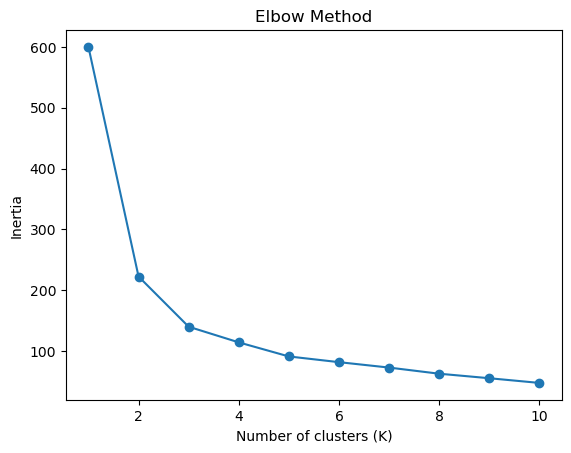

Silhouette Score: 0.45994823920518635


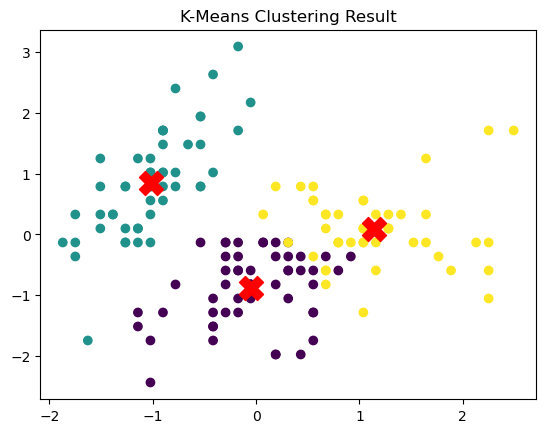

In [11]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
iris = load_iris()
X = iris.data

# 2. Feature scaling (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Elbow Method (Inertia)
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.show()

# 4. Fit final KMeans (choose K = 3 for iris)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# 5. Silhouette Score
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

# 6. Visualize clusters (first 2 features)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300, c='red', marker='X')
plt.title("K-Means Clustering Result")
plt.show()

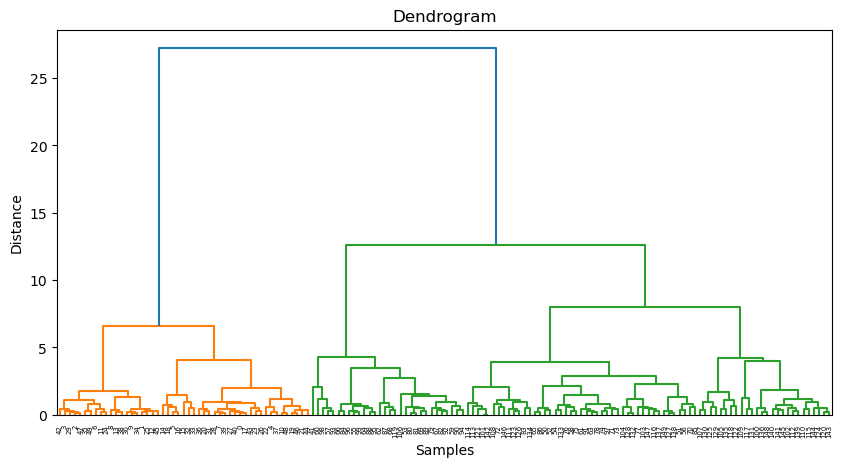

Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 0 2 0 2 0 2 2 2 2 0 0 0 0
 0 0 0 0 0 2 2 2 2 0 2 0 0 2 2 2 2 0 2 2 2 2 2 0 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [12]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Load dataset
iris = load_iris()
X = iris.data

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create linkage matrix
linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# Hierarchical Clustering
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)
labels = hc.fit_predict(X_scaled)
print("Cluster Labels:")
print(labels)